In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from medmnist import ChestMNIST
import numpy as np
import matplotlib.pyplot as plt

In [18]:
import torchvision.transforms as transforms
from torch.utils.data import Subset

torch.manual_seed(42)
np.random.seed(42)

# Transform avec augmentation
transform_train = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

transform_test = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

train_dataset = ChestMNIST(split='train', download=True, size=64, transform=transform_train)
val_dataset   = ChestMNIST(split='val',   download=True, size=64, transform=transform_test)
test_dataset  = ChestMNIST(split='test',  download=True, size=64, transform=transform_test)

train_dataset = Subset(train_dataset, range(10000))
val_dataset   = Subset(val_dataset,   range(2000))
test_dataset  = Subset(test_dataset,  range(3000))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          generator=torch.Generator().manual_seed(42))
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print("Data chargée ")

Data chargée 


In [19]:
class CNNScratch(nn.Module):
    def __init__(self, num_classes=14):
        super(CNNScratch, self).__init__()
        
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 64 -> 32

            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32 -> 16

            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16 -> 8
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
            # Pas de sigmoid ici, on l'applique dans la loss
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNNScratch(num_classes=14)
print(model)

CNNScratch(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=Tru

In [20]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
    def forward(self, inputs, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
model = model.to(device)
torch.manual_seed(42)
np.random.seed(42)

criterion = FocalLoss(gamma=2.0, alpha=0.25)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
print("Setup avec Focal Loss ")

Device : cpu
Setup avec Focal Loss 


In [21]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        running_loss = 0
        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # ── Validation ──
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.float().to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=6)

Epoch [1/6] | Train Loss: 0.0172 | Val Loss: 0.0127
Epoch [2/6] | Train Loss: 0.0141 | Val Loss: 0.0124
Epoch [3/6] | Train Loss: 0.0137 | Val Loss: 0.0124
Epoch [4/6] | Train Loss: 0.0134 | Val Loss: 0.0127
Epoch [5/6] | Train Loss: 0.0133 | Val Loss: 0.0121
Epoch [6/6] | Train Loss: 0.0130 | Val Loss: 0.0122


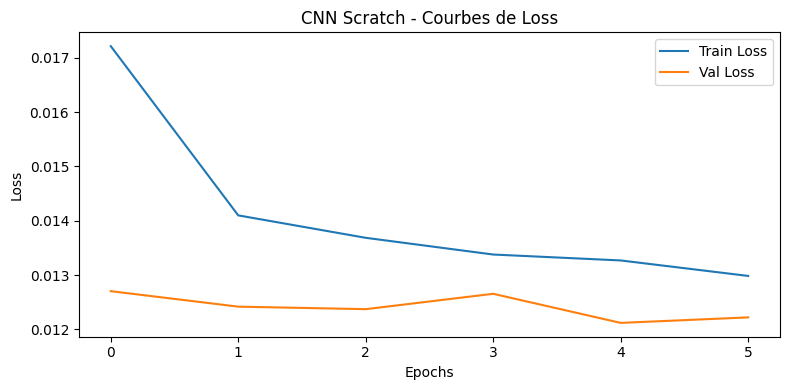

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Scratch - Courbes de Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

label_names = ['atelectasis', 'cardiomegaly', 'effusion', 'infiltration',
               'mass', 'nodule', 'pneumonia', 'pneumothorax',
               'consolidation', 'edema', 'emphysema', 'fibrosis', 'pleural', 'hernia']

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(model(imgs))
        all_preds.append(outputs.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
all_preds_binary = (all_preds >= 0.1).astype(int)

print("=" * 65)
print(f"{'Pathologie':<20} | {'AUC':>6} | {'F1':>6} | {'Recall':>6} | {'Precision':>9}")
print("=" * 65)

aucs, f1s, recalls, precisions = [], [], [], []
for i, name in enumerate(label_names):
    auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
    f1 = f1_score(all_labels[:, i], all_preds_binary[:, i], zero_division=0)
    recall = recall_score(all_labels[:, i], all_preds_binary[:, i], zero_division=0)
    precision = precision_score(all_labels[:, i], all_preds_binary[:, i], zero_division=0)
    aucs.append(auc)
    f1s.append(f1)
    recalls.append(recall)
    precisions.append(precision)
    print(f"{name:<20} | {auc:>6.4f} | {f1:>6.4f} | {recall:>6.4f} | {precision:>9.4f}")

print("=" * 65)
print(f"{'Moyenne':<20} | {np.mean(aucs):>6.4f} | {np.mean(f1s):>6.4f} | {np.mean(recalls):>6.4f} | {np.mean(precisions):>9.4f}")

torch.save(model.state_dict(), 'models/cnn_scratch.pth')
print("\nModèle sauvegardé")

Pathologie           |    AUC |     F1 | Recall | Precision
atelectasis          | 0.6391 | 0.2031 | 1.0000 |    0.1130
cardiomegaly         | 0.6348 | 0.0558 | 1.0000 |    0.0287
effusion             | 0.7424 | 0.2343 | 1.0000 |    0.1327
infiltration         | 0.6406 | 0.3022 | 1.0000 |    0.1780
mass                 | 0.5848 | 0.0989 | 1.0000 |    0.0520
nodule               | 0.5064 | 0.1067 | 1.0000 |    0.0563
pneumonia            | 0.6228 | 0.0219 | 1.0000 |    0.0111
pneumothorax         | 0.6183 | 0.0928 | 1.0000 |    0.0487
consolidation        | 0.7232 | 0.0794 | 1.0000 |    0.0413
edema                | 0.7598 | 0.0460 | 1.0000 |    0.0235
emphysema            | 0.5798 | 0.0437 | 1.0000 |    0.0223
fibrosis             | 0.5227 | 0.0263 | 1.0000 |    0.0133
pleural              | 0.5909 | 0.0601 | 1.0000 |    0.0310
hernia               | 0.7238 | 0.0088 | 0.5000 |    0.0044
Moyenne              | 0.6350 | 0.0986 | 0.9643 |    0.0540

Modèle sauvegardé
